In [113]:
import obspy
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import pandas as pd
import ast
from pathlib import Path
from typing import Optional, List, Tuple, Dict, Any
from obspy.signal.filter import envelope
#from enveloc.core import XCOR
from obspy.clients.fdsn import Client
from obspy.core.util import AttribDict
import numpy as np
from obspy import Stream

import os, json, shutil, subprocess
from glob import glob
from obspy import UTCDateTime, Inventory
import plotly.graph_objects as go

import re
import os
from obspy.io.sac import SACTrace


import numpy as np
from scipy.signal import hilbert

import os, json, shutil, subprocess
from glob import glob
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from obspy.core import UTCDateTime
from obspy.geodetics.base import gps2dist_azimuth

In [114]:
def conv_to_datetime(df):
    new_df = []
    for i in range(len(df)):
        year = int(df[i].split('_')[0])
        month = int(df[i].split('_')[1])
        day = int(df[i].split('_')[2].split(' ')[0])
        hour = int(df[i].split('_')[2].split(' ')[1][0:2])
        minute = int(df[i].split('_')[2].split(' ')[1][2:4])
        second = int(df[i].split('_')[2].split(' ')[1][4:])
        new_df.append(obspy.UTCDateTime(year, month, day, hour, minute, second))
        
    return np.array(new_df)

In [115]:
client = Client('IRIS')
mt_rainier_cat = pd.read_csv('../src/pnw_events_esec.txt', sep = '|')

mt_rainier_cat['starttime'] = conv_to_datetime(mt_rainier_cat['starttime'])
mt_rainier_cat['endtime'] = conv_to_datetime(mt_rainier_cat['endtime'])

pd.set_option('display.max_columns', None)
mt_rainier_cat



ev_lats = mt_rainier_cat['latitude']
ev_lons = mt_rainier_cat['longitude']
ev_starttimes = mt_rainier_cat['starttime']
ev_endtimes = mt_rainier_cat['endtime']
ev_types = mt_rainier_cat['type']
ev_subtypes = mt_rainier_cat['subtype']
ev_evids = mt_rainier_cat['eventid']
ev_locuncerts = mt_rainier_cat['locuncertKm']
ev_dataqualities = mt_rainier_cat['otherdataquality1to5']
ev_names = mt_rainier_cat['name']


In [116]:
# Pick the FDSN client you normally use.
# Try "IRIS" (EarthScope), or a regional one if you have it.
client = Client("IRIS")

north, east, south, west = np.max(ev_lats)+2, np.max(ev_lons)+2, np.min(ev_lats)-2, np.min(ev_lons)- 2

# Infrasound/pressure channels: instrument code "D"
inv = client.get_stations(
    minlatitude=south, maxlatitude=north,
    minlongitude=west, maxlongitude=east,
    channel="*DF",   # pressure channels (e.g., BDF, HDF, LDF)
    level="channel"
)

print(inv)  # inspect what networks/stations/channels you got


Inventory created at 2026-03-06T22:07:38.925100Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?channel=%2ADF&minlat...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (10):
			1A, 8J, C0, CC, SB, TA, UO, UW, ZD, ZK
		Stations (125):
			1A.FLM1 (Top of flume)
			1A.FLM2 (Partway down flume)
			1A.FLM3 (Partway down flume)
			1A.FLM4 (Bottom of flume, attached to shed)
			1A.FLM5 (Runout pad, center of flow)
			1A.FLM6 (Runout pad, azimuthal arc)
			1A.FLM7 (Runout pad, azimuthal arc)
			1A.FLM8 (Runout pad, perpendicular to flow runout)
			1A.FLMA (Flume Crossbeam, location 1)
			1A.FLMB (Flume Crossbeam, location 2)
			1A.FLME (Flume array east)
			1A.FLMW (Flume infrasound array west)
			8J.CHIP (CHIP)
			8J.PHAB (PHAB)
			8J.RAIN (RAIN)
			C0.PALI (Palisades)
			CC.ARAT (Mount Ararat)
			CC.BRSP (Barrett Spur)
			CC.COPP (COPP)
			CC.CPCO (Central Pumice Cone, Newberry Volcano)
			CC.CRBN (Carbon R

In [117]:
def normalize_stream_by_max(st):
    """
    Normalize each trace by its absolute maximum amplitude.
    """
    st = st.copy()
    for tr in st:
        maxamp = np.max(np.abs(tr.data))
        if maxamp > 0:
            tr.data = tr.data / maxamp
    return st



def compute_snr(tr):
    """
    SNR = max(abs(tr)) / mean(abs(tr))
    """
    data = tr.data.astype(float)
    abs_data = np.abs(data)

    mean_abs = np.mean(abs_data)
    if mean_abs == 0:
        return 0

    return np.max(abs_data) / mean_abs


def drop_low_snr_traces(st, threshold=0, verbose=True):
    """
    Removes traces with SNR < threshold.

    Parameters
    ----------
    st : obspy.Stream
    threshold : float
        Minimum SNR required to keep trace.
    verbose : bool
        Print info about removed traces.

    Returns
    -------
    cleaned_stream : obspy.Stream
    """

    cleaned_stream = Stream()

    for tr in st:
        snr = compute_snr(tr)

        if snr >= threshold:
            cleaned_stream += tr
        else:
            if verbose:
                print(f"Dropping {tr.id} | SNR = {snr:.2f}")

    if verbose:
        print(f"\nKept {len(cleaned_stream)} / {len(st)} traces (threshold = {threshold})")

    return cleaned_stream
    
    
    

def preprocess_infrasound(st, inv=None, taper=0.05, freqmin= 0.5, freqmax= 5):
    """
    Simple, safe preprocessing for infrasound:
    - merge gaps
    - detrend
    - taper
    - bandpass
    Optionally remove instrument response if inventory provided.
    """
    if len(st) == 0:
        return st

    st = st.copy()
    st.merge(method=1, fill_value="interpolate")  # handle small gaps
    st.detrend("linear")
    st.detrend("demean")
    st.taper(max_percentage=taper)

    # Optional response removal (only if you have correct response metadata)
    # If you do remove_response, choose output="PA" if the response supports it.
    # if inv is not None:
    #     st.remove_response(inventory=inv, output="PA", water_level=60)
    
    for tr in st:
        df = tr.stats.sampling_rate
        nyquist = df / 2

        if freqmin <= 0:
            raise ValueError("freqmin must be > 0")

        if freqmin >= nyquist:
            print(f"Skipping {tr.id}: freqmin >= Nyquist")
            continue

        safe_freqmax = min(freqmax, nyquist * 0.99)

        tr.filter(
            "bandpass",
            freqmin=freqmin,
            freqmax=safe_freqmax,
            corners=4,
            zerophase=True
        )
        
        
    
    return st




def moving_average(x, win_samples: int):
    if win_samples <= 1:
        return x
    w = np.ones(win_samples, dtype=float) / win_samples
    return np.convolve(x, w, mode="same")

def envelope_snr(
    tr,
    smooth_sec: float = 0.5,      # envelope smoothing window
    baseline: str = "median",     # "median" or "mean"
    quantile_peak: float = 0.99,  # use robust peak instead of absolute max
    eps: float = 1e-12,
):
    """
    Robust envelope-SNR:
      peak = q-quantile of smoothed envelope (avoids single-sample spikes)
      noise = median (or mean) of smoothed envelope
      SNR = peak / noise
    """
    x = np.asarray(tr.data, dtype=float)
    if x.size == 0:
        return np.nan

    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    fs = float(tr.stats.sampling_rate)
    win = max(1, int(round(smooth_sec * fs)))

    env = np.abs(hilbert(x))
    env_s = moving_average(env, win)

    # robust "peak"
    peak = np.quantile(env_s, quantile_peak)

    if baseline == "median":
        noise = np.median(env_s)
    elif baseline == "mean":
        noise = np.mean(env_s)
    else:
        raise ValueError("baseline must be 'median' or 'mean'")

    if (not np.isfinite(noise)) or noise < eps:
        return np.nan
    return float(peak / noise)



def filter_arrays_by_envelope_snr(
    st,
    snr_threshold= 2.0,
    agg="mean",          # "mean" or "median"
    **env_kwargs         # passed to envelope_snr()
):
    """
    Filters entire infrasound arrays (net, sta) whose aggregated envelope SNR
    is below snr_threshold.

    Returns:
        st_filtered
        array_snr_dict
    """

    from collections import defaultdict

    arrays = defaultdict(list)
    trace_snr_map = {}

    # --- Compute envelope SNR per trace ---
    for tr in st:
        key = (tr.stats.network, tr.stats.station)
        arrays[key].append(tr)
        trace_snr_map[tr.id] = envelope_snr(tr, **env_kwargs)

    # --- Aggregate per array ---
    array_snr = {}
    for key, trs in arrays.items():
        snrs = np.array([trace_snr_map[t.id] for t in trs], dtype=float)
        snrs = snrs[np.isfinite(snrs)]

        if snrs.size == 0:
            array_snr[key] = np.nan
        else:
            if agg == "median":
                array_snr[key] = float(np.median(snrs))
            else:
                array_snr[key] = float(np.mean(snrs))

    # --- Decide which arrays to keep ---
    keep_arrays = {
        key for key, val in array_snr.items()
        if np.isfinite(val) and val >= snr_threshold
    }

    # --- Filter stream ---
    st_filtered = Stream([
        tr for tr in st
        if (tr.stats.network, tr.stats.station) in keep_arrays
    ])

    print(f"Kept {len(keep_arrays)} arrays")
    print(f"Dropped {len(array_snr) - len(keep_arrays)} arrays")

    return st_filtered, array_snr










def merge_overlaps_by_id(st, fill="interpolate"):
    out = Stream()
    for tr_id in sorted({tr.id for tr in st}):
        s = st.select(id=tr_id).copy()
        s.sort(keys=["starttime"])
        # This merges overlaps/gaps into as few traces as possible
        s.merge(method=1, fill_value=fill)  # method=1 is “interpolate small gaps”
        out += s
    return out




def drop_exact_clones(st: Stream) -> Stream:
    """
    Drop exact duplicate traces by id + start/end + npts.
    Uses only primitive types in the key to avoid hashing issues.
    """
    seen = set()
    out = Stream()

    for tr in st:
        # Convert UTCDateTime -> nanoseconds integer (safe + hashable)
        s_ns = int(tr.stats.starttime.ns)
        e_ns = int(tr.stats.endtime.ns)

        key = (str(tr.id), s_ns, e_ns, int(tr.stats.npts))

        if key not in seen:
            out += tr
            seen.add(key)

    return out





def group_by_array(st):
    arrays = defaultdict(Stream)
    for tr in st:
        net, sta, loc, cha = tr.id.split(".")
        arrays[(net, sta)] += tr
    return arrays


from obspy.core.util import AttribDict

def attach_coordinates_from_inventory(st, inv):
    """
    Attach per-trace coordinates using a channel-level Inventory.
    """
    for tr in st:
        net = tr.stats.network
        sta = tr.stats.station
        loc = tr.stats.location or ""
        cha = tr.stats.channel

        sel = inv.select(network=net, station=sta, location=loc, channel=cha)
        if len(sel.networks) == 0 or len(sel.networks[0].stations) == 0 or len(sel.networks[0].stations[0].channels) == 0:
            # no match
            continue

        ch = sel.networks[0].stations[0].channels[0]
        tr.stats.coordinates = AttribDict({
            "latitude": float(ch.latitude),
            "longitude": float(ch.longitude),
            "elevation": float(ch.elevation),
        })
    return st



from obspy.core.util import AttribDict

def attach_coordinates_from_inventory(st, inv, strict=True):
    missing = []
    for tr in st:
        net = tr.stats.network
        sta = tr.stats.station
        loc = tr.stats.location or ""
        cha = tr.stats.channel

        sel = inv.select(network=net, station=sta, location=loc, channel=cha)
        ok = (len(sel.networks) and len(sel.networks[0].stations) and len(sel.networks[0].stations[0].channels))
        if not ok:
            missing.append(tr.id)
            if strict:
                continue  # collect all missing first
            else:
                continue

        ch = sel.networks[0].stations[0].channels[0]
        tr.stats.coordinates = AttribDict(
            latitude=float(ch.latitude),
            longitude=float(ch.longitude),
            elevation=float(ch.elevation),
        )

    if strict and missing:
        raise ValueError(f"Missing channel metadata for {len(missing)} traces. Examples: {missing[:20]}")

    return st





def write_array_to_sac(st_array, outdir):
    os.makedirs(outdir, exist_ok=True)
    for tr in st_array:
        c = tr.stats.coordinates
        sac = SACTrace.from_obspy_trace(tr)
        sac.stla = float(c.latitude)
        sac.stlo = float(c.longitude)
        sac.stel = float(c.elevation)
        fn = f"{tr.id.replace('.', '_')}.SAC"
        sac.write(os.path.join(outdir, fn))
        





def _get_channel_latlon(inv, network, station, location, channel):
    try:
        inv_sel = inv.select(network=network, station=station, location=location, channel=channel)
        if len(inv_sel) == 0:
            return None
        ch = inv_sel[0][0][0]
        if getattr(ch, "latitude", None) is None or getattr(ch, "longitude", None) is None:
            return None
        return float(ch.latitude), float(ch.longitude)
    except Exception:
        return None


def plot_pretty_infrasound_multiloc(
    st,
    event_idx,
    t0,
    t1,
    freqmin,
    freqmax,
    inv=None,
    event_lat=None,
    event_lon=None,
    sort_by_distance=True,
    closest_on_top=True,
    linewidth=0.9,
    station_spacing=3.2,      # <-- MORE space between stations
    trace_spacing=0.9,        # <-- MORE space between traces within a station
    trace_scale=0.55,         # <-- shrink waveform amplitude (0.3–0.7 works well)
    figsize=(16, 9),
    show_distance_in_station_label=True,
    show_loc_chan_labels=True,
):
    if len(st) == 0:
        print("Empty stream.")
        return None

    # ---- group traces by station (NET.STA) for coloring ----
    station_groups = defaultdict(list)
    for tr in st:
        station_key = f"{tr.stats.network}.{tr.stats.station}"
        station_groups[station_key].append(tr)

    # ---- compute per-trace distances (km) ----
    trace_dist_km = {}
    if sort_by_distance and inv is not None and event_lat is not None and event_lon is not None:
        for tr in st:
            net = tr.stats.network
            sta = tr.stats.station
            loc = (tr.stats.location or "").strip()
            cha = tr.stats.channel

            latlon = _get_channel_latlon(inv, net, sta, loc, cha)
            if latlon is None:
                trace_dist_km[id(tr)] = np.inf
            else:
                slat, slon = latlon
                d_m, _, _ = gps2dist_azimuth(event_lat, event_lon, slat, slon)
                trace_dist_km[id(tr)] = d_m / 1000.0
    else:
        for tr in st:
            trace_dist_km[id(tr)] = np.nan

    # ---- sort stations by min distance ----
    station_keys = list(station_groups.keys())
    if sort_by_distance and np.isfinite([
        min(trace_dist_km[id(tr)] for tr in station_groups[k]) for k in station_keys
    ]).any():
        station_keys.sort(key=lambda k: min(trace_dist_km[id(tr)] for tr in station_groups[k]))
    else:
        station_keys.sort()

    # ---- station color map ----
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    station_to_color = {k: colors[i % len(colors)] for i, k in enumerate(station_keys)}

    fig, ax = plt.subplots(figsize=figsize)

    nstations = len(station_keys)

    def station_base_offset(i):
        # closest at top (higher y)
        if closest_on_top:
            return (nstations - 1 - i) * station_spacing
        return i * station_spacing

    for i, skey in enumerate(station_keys):
        trs = station_groups[skey]
        color = station_to_color[skey]

        trs_sorted = sorted(
            trs,
            key=lambda tr: (
                trace_dist_km.get(id(tr), np.inf),
                (tr.stats.location or ""),
                tr.stats.channel
            )
        )

        base = station_base_offset(i)

        # station label
        station_min_km = np.nan
        if sort_by_distance and inv is not None and event_lat is not None and event_lon is not None:
            station_min_km = np.min([trace_dist_km[id(tr)] for tr in trs_sorted]) if trs_sorted else np.nan

        if show_distance_in_station_label and np.isfinite(station_min_km):
            station_label = f"{skey}  ({station_min_km:.1f} km)"
        else:
            station_label = skey

        ax.text(
            -0.01, base,
            station_label,
            transform=ax.get_yaxis_transform(),
            ha="right",
            va="center",
            fontsize=10,
            clip_on=False
        )

        # plot each trace within station band without overlap
        ntr = len(trs_sorted)
        for j, tr in enumerate(trs_sorted):
            # spread traces around the station base line
            within = (j - (ntr - 1) / 2.0) * trace_spacing
            yoff = base + within

            data = tr.data.astype(np.float64)
            mx = np.max(np.abs(data)) if len(data) else 1.0
            if mx == 0:
                mx = 1.0
            data = (data / mx) * trace_scale  # <-- shrink amplitude

            t = np.arange(len(data)) / tr.stats.sampling_rate
            ax.plot(t, data + yoff, lw=linewidth, alpha=0.95, color=color)

            if show_loc_chan_labels:
                loc = (tr.stats.location or "--").strip()
                chan = tr.stats.channel
                lc_lbl = f"{loc}.{chan}"
                ax.text(
                    0.005, yoff + 0.2,
                    lc_lbl,
                    transform=ax.get_yaxis_transform(),
                    ha="left",
                    va="center",
                    fontsize=8,
                    alpha=0.85,
                    clip_on=False
                )

    ax.set_yticks([])
    ax.set_xlabel("Time (s)")
    ax.set_title(
        f"Normalized Waveforms (Bandpass {freqmin}-{freqmax} Hz)",
        weight="bold"
    )
    ax.grid(True, alpha=0.25)
    ax.set_xlim(left=0)

    plt.subplots_adjust(left=0.28, right=0.98, top=0.90, bottom=0.10)
    plt.show()
    return fig, ax



        

def plot_event_infrasound(mt_rainier_cat, event_idx, inv, client,
                          pad_before= 20, pad_after=100,
                          freqmin= 1.0, freqmax=10.0,
                          max_traces= 2e+10, snr_thresh = 2):
    """
    mt_rainier_cat: must let you access start/end as UTCDateTime or ISO string
    event_idx: index of event row
    inv: station inventory returned by get_stations (level="channel")
    """
    # ---- get start/end from your catalog row ----
    row = mt_rainier_cat.iloc[event_idx]  # if it's a pandas DF
    t0 = row["starttime"]
    t1 = row["endtime"]

    # Make sure UTCDateTime
    if not isinstance(t0, UTCDateTime):
        t0 = UTCDateTime(t0)
    if not isinstance(t1, UTCDateTime):
        t1 = UTCDateTime(t1)

    tstart = t0 - pad_before
    tend   = t1 + pad_after

    # ---- gather infrasound traces ----
    st_all = Stream()
    picked = 0

    for net in inv:
        for sta in net:
            for cha in sta:
                code = cha.code
                if len(code) == 3 and code[1] != "D":
                    continue
                loc = cha.location_code or ""

                try:
                    st = client.get_waveforms(
                        network=net.code, station=sta.code, location=loc, channel=code,
                        starttime=tstart, endtime=tend, attach_response=False
                    )
                except Exception:
                    continue

                if len(st) == 0:
                    continue

                st = preprocess_infrasound(st, inv=None, freqmin=freqmin, freqmax=freqmax)
                st_all += st
                picked += len(st)
                if picked >= max_traces:
                    break
            if picked >= max_traces:
                break
        if picked >= max_traces:
            break

    if len(st_all) == 0:
        print(f"No infrasound data found for event {event_idx} in window {tstart} - {tend}")
        return None

    # ---- plot ----
    # ObsPy's built-in plotting is quick; it makes a stacked plot per trace
    # Normalize each trace individually
    
    
    

    st_all = merge_overlaps_by_id(st_all, fill="interpolate")
    st_all = drop_exact_clones(st_all)
    st_all = drop_low_snr_traces(st_all, verbose = False)
    
    
    st_all, array_snr = filter_arrays_by_envelope_snr(
    st_all,
    snr_threshold= snr_thresh,
    agg="mean",
    smooth_sec=0.5,
    baseline="median",
    quantile_peak=0.99)
    
    

    st_norm = normalize_stream_by_max(st_all)
    
    plt.style.use('default')

    event_lat = row.get("latitude", None)
    event_lon = row.get("longitude", None)

    plot_pretty_infrasound_multiloc(
        st_norm, event_idx, t0, t1, freqmin, freqmax,
        inv=inv, event_lat=event_lat, event_lon=event_lon,
        station_spacing=3.5,
        trace_spacing=1.0,
        trace_scale=0.45
    )

    return st_all


In [118]:
df = mt_rainier_cat[mt_rainier_cat['eventid'] == 327]

In [119]:
import obspy

# Define the stations you want to keep
# Format: {network: [list of station codes]}
desired_stations = {
    "CC": ["ARAT", "COPP", "KAUT", "MILD", "PARA", "TAVI"],
    "UW": ["RER"]
}

# Filter the inventory
filtered_inv = obspy.Inventory(networks=[], source=inv.source)

for net_code, sta_codes in desired_stations.items():
    # Get the network from the inventory
    net = inv.select(network=net_code)
    if not net:
        continue
    
    for sta_code in sta_codes:
        selected = inv.select(network=net_code, station=sta_code)
        if selected:
            # Merge into filtered inventory
            filtered_inv += selected

print(filtered_inv)

Inventory created at 2026-03-06T22:07:43.031870Z
	Created by: ObsPy 1.4.1
		    https://www.obspy.org
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (7):
			CC (6x), UW
		Stations (7):
			CC.ARAT (Mount Ararat)
			CC.COPP (COPP)
			CC.KAUT (Kautz Creek Helibase)
			CC.MILD (Mildred Point)
			CC.PARA (Paradise Precip Tower)
			CC.TAVI (Tahoma Vista)
			UW.RER (Emerald Ridge, Mount Rainier, WA, USA)
		Channels (82):
			CC.ARAT.01.BDF (2x), CC.ARAT.01.CDF, CC.ARAT.01.HDF, 
			CC.ARAT.02.BDF (2x), CC.ARAT.02.CDF, CC.ARAT.02.HDF, 
			CC.ARAT.03.BDF (2x), CC.ARAT.03.CDF, CC.ARAT.03.HDF, CC.ARAT.04.HDF
			CC.ARAT.05.HDF, CC.ARAT.11.HDF (2x), CC.ARAT.12.HDF, 
			CC.ARAT.13.HDF, CC.ARAT.14.HDF, CC.ARAT.15.HDF, CC.COPP.01.BDF (3x)
			CC.COPP.01.CDF, CC.COPP.02.BDF (3x), CC.COPP.02.CDF, 
			CC.COPP.03.BDF (3x), CC.COPP.03.CDF, CC.KAUT.01.BDF (3x), 
			CC.KAUT.01.CDF (2x), CC.KAUT.02.BDF (2x), CC.KAUT.02.CDF, 
			CC.KAUT.03.BDF (3x), CC.KAUT.03.CDF, CC.MILD.01.BDF (2x), 
			CC.MIL

Kept 7 arrays
Dropped 0 arrays


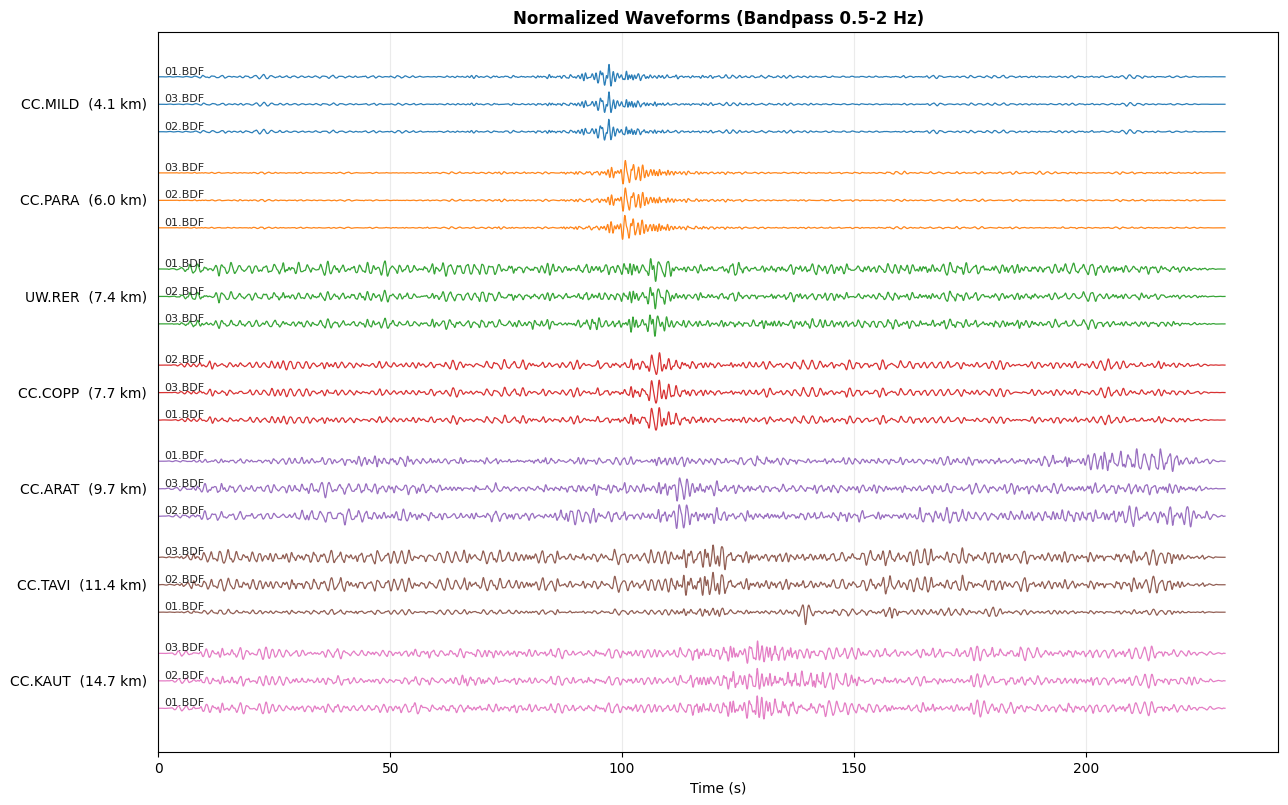

In [121]:
for i in range(len(df)):
    
      # 1) build stream for event i
        st_all = plot_event_infrasound(df, i, filtered_inv, client, freqmin = 0.5, freqmax = 2, snr_thresh = 2)